# Statistics & Probability — Distributions, Bayes, MLE, CLT, KS Test, KL Divergence

*Part of the ML Course Reference Series.*

## Q27: What is a PMF, PDF, and CDF?

| | PMF | PDF | CDF |
|---|---|---|---|
| **Used for** | Discrete variables | Continuous variables | Both |
| **Gives** | P(X = x) | Density at x (not probability) | P(X ≤ x) |
| **Integrates to** | 1 (sum) | 1 (integral) | Reaches 1 at the right |

Example: rolling a die → PMF.  Height of a person → PDF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
sns.set_theme(style='whitegrid')
np.random.seed(42)


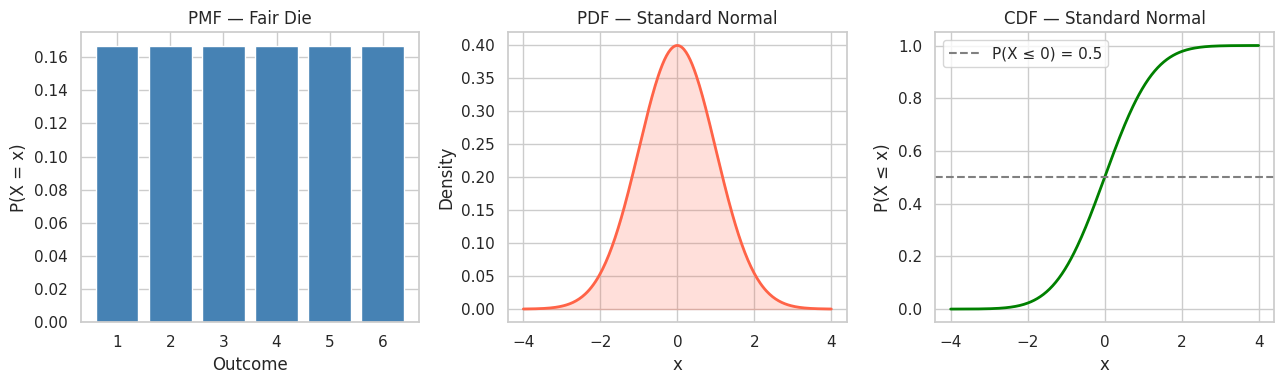

In [2]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# PMF — fair die
faces = np.arange(1, 7)
axes[0].bar(faces, [1/6]*6, color='steelblue', edgecolor='white')
axes[0].set_title('PMF — Fair Die')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('P(X = x)')

# PDF — standard normal
x = np.linspace(-4, 4, 300)
axes[1].plot(x, norm.pdf(x), color='tomato', linewidth=2)
axes[1].fill_between(x, norm.pdf(x), alpha=0.2, color='tomato')
axes[1].set_title('PDF — Standard Normal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')

# CDF — standard normal
axes[2].plot(x, norm.cdf(x), color='green', linewidth=2)
axes[2].axhline(0.5, color='gray', linestyle='--', label='P(X ≤ 0) = 0.5')
axes[2].set_title('CDF — Standard Normal')
axes[2].set_xlabel('x')
axes[2].set_ylabel('P(X ≤ x)')
axes[2].legend()

plt.tight_layout()
plt.show()

## Q28: What is Bayes' Theorem?

Bayes' theorem updates the probability of a hypothesis given new evidence:

```
P(H | E) = P(E | H) × P(H) / P(E)
```

- **P(H)** — prior: what you believed before seeing evidence
- **P(E|H)** — likelihood: probability of evidence if hypothesis is true
- **P(H|E)** — posterior: updated belief after seeing evidence

This is the foundation of Naive Bayes classifiers and probabilistic ML.

In [3]:
# Medical test example
scenarios = [
    ('Rare disease (1%)',    0.01),
    ('Common disease (10%)', 0.10),
    ('Very common (40%)',    0.40),
]

sensitivity = 0.99   # P(test+ | disease)
fpr         = 0.05   # P(test+ | no disease)

print(f'Test sensitivity: {sensitivity*100:.0f}%  False positive rate: {fpr*100:.0f}%')
print('-' * 55)

for label, prevalence in scenarios:
    p_positive = sensitivity * prevalence + fpr * (1 - prevalence)
    posterior  = (sensitivity * prevalence) / p_positive
    print(f'{label:25s} → P(disease | positive) = {posterior:.2%}')

Test sensitivity: 99%  False positive rate: 5%
-------------------------------------------------------
Rare disease (1%)         → P(disease | positive) = 16.67%
Common disease (10%)      → P(disease | positive) = 68.75%
Very common (40%)         → P(disease | positive) = 92.96%


## Q29: What is Maximum Likelihood Estimation (MLE)?

MLE finds the parameter values that make the observed data most probable:

```
θ_MLE = argmax_θ  P(data | θ)
```

In practice we maximise the **log-likelihood** (easier to compute, same answer).

Example: estimating the mean and std of a Gaussian from data. MLE gives `μ = sample_mean`, `σ = sample_std`.

In [4]:
from scipy.stats import norm
from scipy.optimize import minimize

# Generate data from N(5, 2)
np.random.seed(42)
data = np.random.normal(loc=5, scale=2, size=200)

def neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    return -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

result = minimize(neg_log_likelihood, x0=[0, 1], args=(data,),
                  bounds=[(None, None), (1e-6, None)])  # sigma must be > 0
mu_mle, sigma_mle = result.x

print(f'True    μ=5, σ=2')
print(f'MLE     μ={mu_mle:.3f}, σ={sigma_mle:.3f}')
print(f'Sample  μ={data.mean():.3f}, σ={data.std():.3f}')
# MLE = sample mean / sample std for Gaussian

True    μ=5, σ=2
MLE     μ=4.918, σ=1.857
Sample  μ=4.918, σ=1.857


## Q29b: What is Variance (Dispersion) and Standard Deviation?

**Variance** measures how spread out values are around the mean:

```
Var(X) = E[(X − μ)²] = (1/n) Σ (xᵢ − μ)²   ← population
                       (1/(n-1)) Σ (xᵢ − μ)²  ← sample (Bessel's correction)
```

**Standard deviation** = √Var(X) — same units as the original variable.

| Concept | Formula | Meaning |
|---|---|---|
| Variance σ² | E[(X−μ)²] | Average squared deviation from mean |
| Std dev σ | √σ² | Typical distance from the mean |
| CV | σ/μ | Relative spread (unit-free) |

**In ML:** high-variance features carry more information but may need scaling. PCA finds directions of maximum variance.

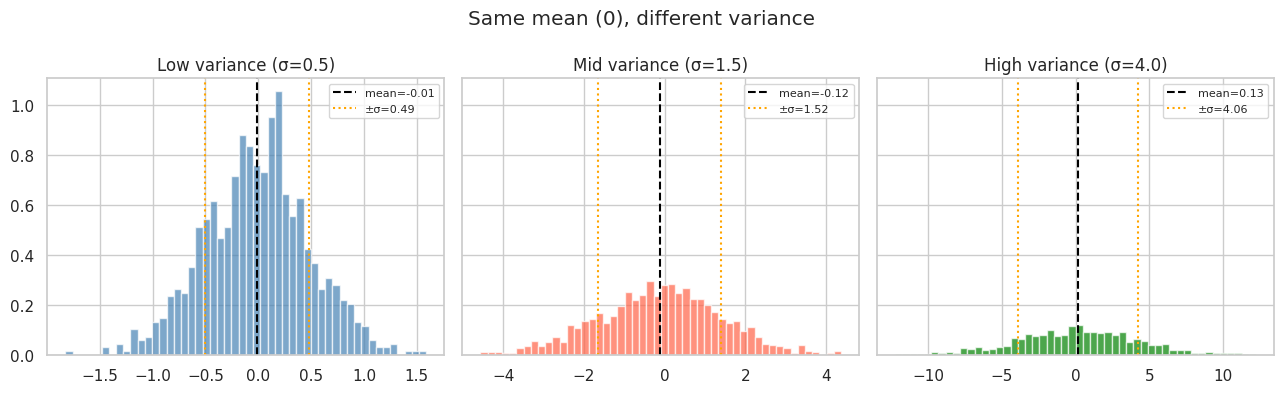

Data: [2. 4. 4. 4. 5. 5. 7. 9.]
Mean:              5.0000
Population var:    4.0000    (divides by n=8)
Sample var:        4.5714  (divides by n-1=7, Bessel correction)
Population std:    2.0000
Sample std:        2.1381
Coeff of variation:0.4000  (relative spread)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Three distributions with same mean, different variance
low_var  = rng.normal(0, 0.5, 1000)
mid_var  = rng.normal(0, 1.5, 1000)
high_var = rng.normal(0, 4.0, 1000)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, data, color, label in zip(
        axes,
        [low_var, mid_var, high_var],
        ['steelblue', 'tomato', 'green'],
        ['Low variance (σ=0.5)', 'Mid variance (σ=1.5)', 'High variance (σ=4.0)']):
    ax.hist(data, bins=50, color=color, alpha=0.7, density=True)
    ax.axvline(data.mean(), color='black', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.axvline(data.mean() + data.std(), color='orange', linestyle=':', label=f'±σ={data.std():.2f}')
    ax.axvline(data.mean() - data.std(), color='orange', linestyle=':')
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle('Same mean (0), different variance')
plt.tight_layout()
plt.show()

# Population vs sample variance
x = np.array([2., 4., 4., 4., 5., 5., 7., 9.])
print(f'Data: {x}')
print(f'Mean:              {x.mean():.4f}')
print(f'Population var:    {x.var():.4f}    (divides by n={len(x)})')
print(f'Sample var:        {x.var(ddof=1):.4f}  (divides by n-1={len(x)-1}, Bessel correction)')
print(f'Population std:    {x.std():.4f}')
print(f'Sample std:        {x.std(ddof=1):.4f}')
print(f'Coeff of variation:{x.std()/x.mean():.4f}  (relative spread)')


## Q29c: What is the Central Limit Theorem (CLT)?

**Statement:** If you draw n independent samples from *any* distribution with finite mean μ and variance σ², 
the distribution of the **sample mean** approaches a Normal distribution as n → ∞:

```
x̄ ~ N(μ,  σ²/n)
```

**What it means in practice:**
- No matter how weird your data distribution looks, averages of large samples are approximately normal.
- This is why we can use t-tests, confidence intervals, and p-values without assuming normality of raw data.
- Cross-validation scores are approximately normal — justifies reporting mean ± std.
- Standard error of the mean (SEM) = σ / √n — larger samples → tighter estimates.

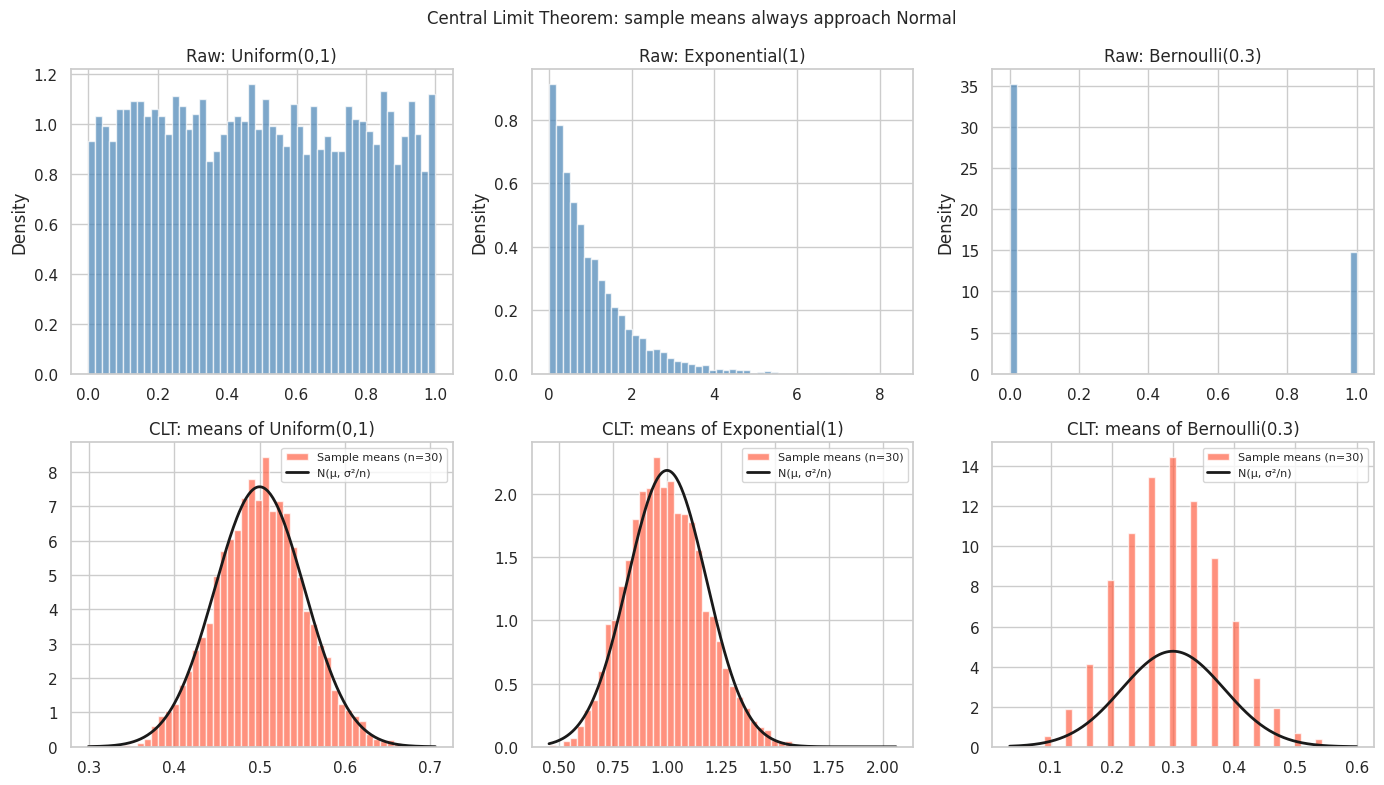

Standard Error of Mean (SEM = σ/√n) for N(0,1):
  n=    5: SEM = 0.4472
  n=   10: SEM = 0.3162
  n=   30: SEM = 0.1826
  n=  100: SEM = 0.1000
  n= 1000: SEM = 0.0316


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)
n_experiments = 5000

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

distributions = [
    ('Uniform(0,1)',   lambda n: rng.uniform(0, 1, n),        0.5,    1/12),
    ('Exponential(1)', lambda n: rng.exponential(1, n),        1.0,    1.0 ),
    ('Bernoulli(0.3)', lambda n: rng.binomial(1, 0.3, n),      0.3,    0.21),
]

for col, (name, sampler, mu, var) in enumerate(distributions):
    # Raw distribution (n=1)
    raw = sampler(n_experiments)
    axes[col].hist(raw, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[col].set_title(f'Raw: {name}')
    axes[col].set_ylabel('Density')

    # Distribution of sample means (n=30)
    n = 30
    means = np.array([sampler(n).mean() for _ in range(n_experiments)])
    sem = np.sqrt(var / n)
    x_range = np.linspace(means.min(), means.max(), 300)

    axes[col + 3].hist(means, bins=50, density=True, color='tomato', alpha=0.7, label=f'Sample means (n={n})')
    axes[col + 3].plot(x_range, norm.pdf(x_range, mu, sem), 'k-', linewidth=2, label='N(μ, σ²/n)')
    axes[col + 3].set_title(f'CLT: means of {name}')
    axes[col + 3].legend(fontsize=8)

plt.suptitle('Central Limit Theorem: sample means always approach Normal', fontsize=12)
plt.tight_layout()
plt.show()

# SEM shrinks with sample size
print('Standard Error of Mean (SEM = σ/√n) for N(0,1):')
for n in [5, 10, 30, 100, 1000]:
    print(f'  n={n:5d}: SEM = {1/np.sqrt(n):.4f}')


## Q29d: How do you visualize a distribution? (Complete toolkit)

| Plot | Best for | Watch out for |
|---|---|---|
| **Histogram** | Raw counts / density | Bin width changes the story |
| **KDE** (kernel density) | Smooth continuous shape | Over-smooths with small data |
| **Box plot** | Median, IQR, outliers | Hides shape (bimodal looks unimodal) |
| **Violin plot** | Shape + summary stats | Harder to read than box for non-experts |
| **ECDF** | Exact quantile reading | Less intuitive visually |
| **Q-Q plot** | Testing normality | Requires knowing expected distribution |

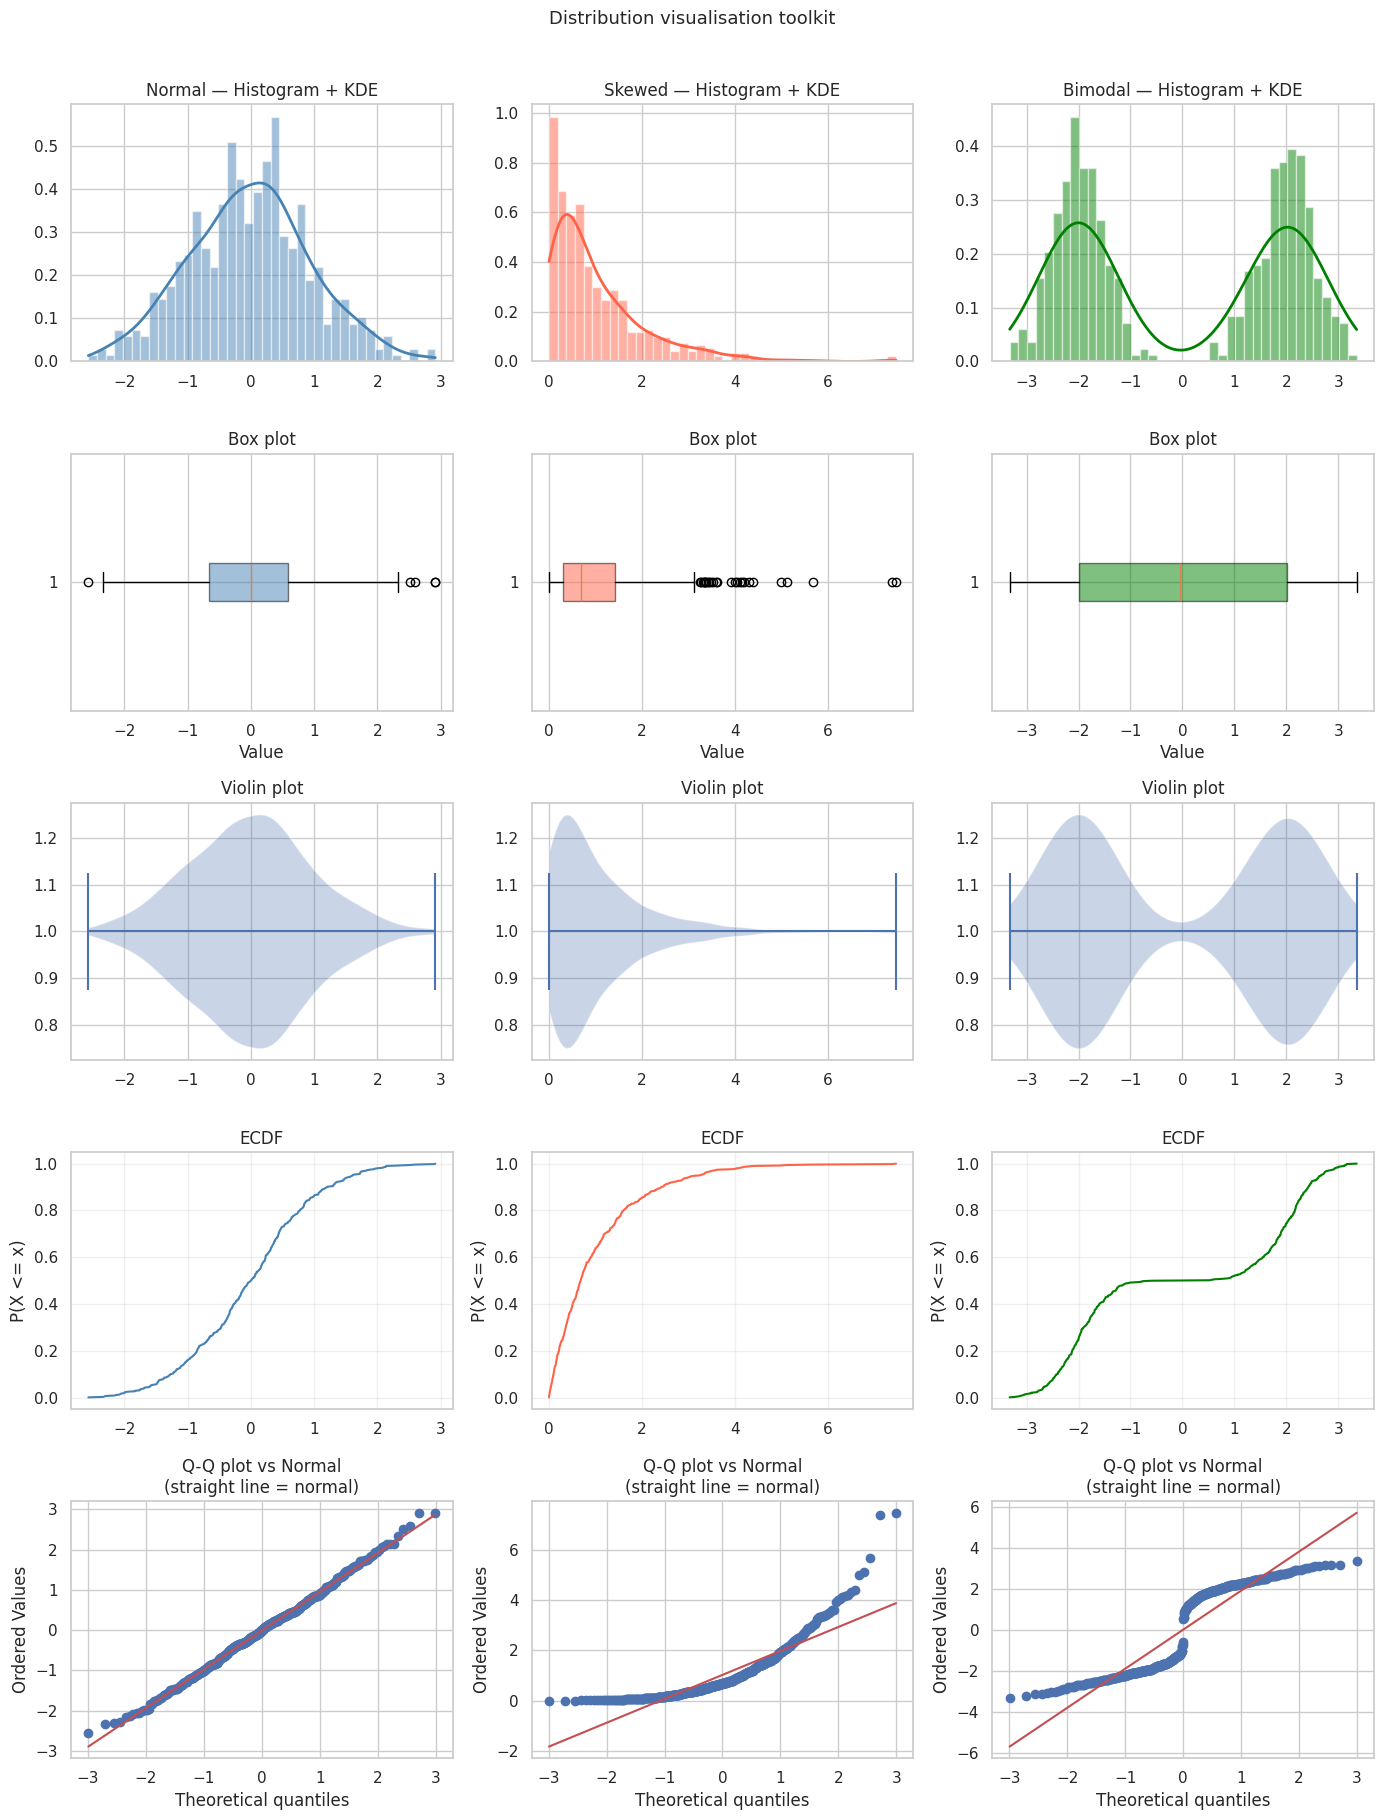

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot, norm
import seaborn as sns

rng = np.random.default_rng(42)
data_normal  = rng.normal(0, 1, 500)
data_skewed  = rng.exponential(1, 500)
data_bimodal = np.concatenate([rng.normal(-2, 0.5, 250), rng.normal(2, 0.5, 250)])

datasets = [('Normal',  data_normal, 'steelblue'),
            ('Skewed',  data_skewed, 'tomato'),
            ('Bimodal', data_bimodal, 'green')]

fig, axes = plt.subplots(5, 3, figsize=(14, 18))

for col, (name, data, color) in enumerate(datasets):
    # Histogram + KDE
    axes[0, col].hist(data, bins=40, density=True, alpha=0.5, color=color)
    x = np.linspace(data.min(), data.max(), 300)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    axes[0, col].plot(x, kde(x), color=color, linewidth=2)
    axes[0, col].set_title(f'{name} — Histogram + KDE')

    # Box plot
    axes[1, col].boxplot(data, vert=False, patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.5))
    axes[1, col].set_title('Box plot')
    axes[1, col].set_xlabel('Value')

    # Violin plot
    axes[2, col].violinplot(data, vert=False)
    axes[2, col].set_title('Violin plot')

    # ECDF
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data)+1) / len(data)
    axes[3, col].plot(sorted_data, ecdf, color=color, linewidth=1.5)
    axes[3, col].set_title('ECDF')
    axes[3, col].set_ylabel('P(X <= x)')
    axes[3, col].grid(True, alpha=0.3)

    # Q-Q plot (vs normal)
    probplot(data, dist='norm', plot=axes[4, col])
    axes[4, col].set_title(f'Q-Q plot vs Normal\n(straight line = normal)')

plt.suptitle('Distribution visualisation toolkit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Q29e: What is the Kolmogorov-Smirnov (KS) Test?

The KS test answers: **are two distributions the same?**

It computes the **D-statistic** = maximum absolute difference between the two empirical CDFs:

```
D = max |F₁(x) − F₂(x)|
```

- Small D → distributions are similar
- p-value < 0.05 → distributions are **significantly different**

**ML use cases:**
- **Data drift detection:** is the production distribution different from training?
- **Train/test mismatch:** did stratification work?
- **Feature distribution check:** is the new batch from the same population?

Two variants:
- **One-sample:** compare data to a theoretical distribution (e.g. is this Normal?)
- **Two-sample:** compare two datasets

One-sample KS (vs Normal):
  Normal data:  D=0.0731, p=0.0768  -> SAME dist
  Skewed data:  D=0.1608, p=0.0000  -> DIFFERENT

Two-sample KS (train vs test):
  No drift:    D=0.0540, p=0.7825  -> OK
  With drift:  D=0.2790, p=0.0000  -> DRIFT DETECTED!


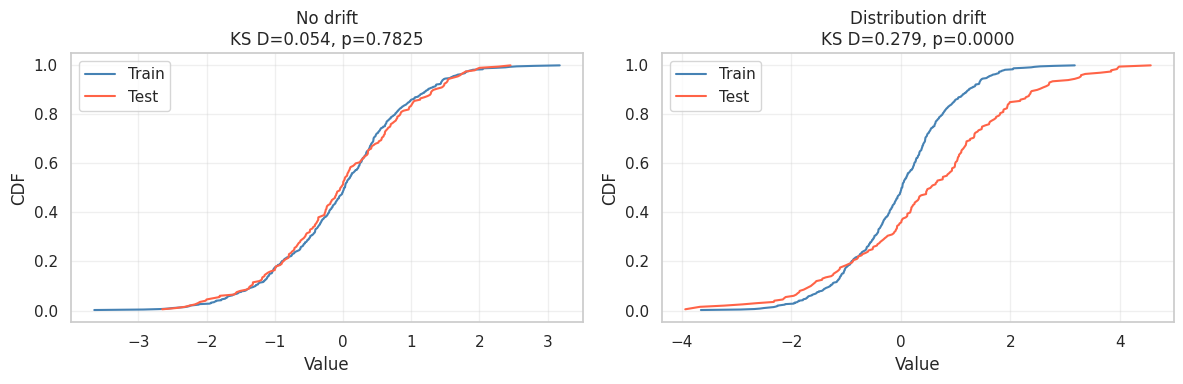

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, kstest, norm

rng = np.random.default_rng(42)

# ── One-sample KS: is data normally distributed? ──────────────────────────────
normal_data = rng.normal(0, 1, 300)
skewed_data = rng.exponential(1, 300)

stat_n, p_n = kstest(normal_data, 'norm', args=(0, 1))
stat_s, p_s = kstest(skewed_data, 'norm', args=(1, 1))
print('One-sample KS (vs Normal):')
print(f'  Normal data:  D={stat_n:.4f}, p={p_n:.4f}  -> {"SAME dist" if p_n > 0.05 else "DIFFERENT"}')
print(f'  Skewed data:  D={stat_s:.4f}, p={p_s:.4f}  -> {"SAME dist" if p_s > 0.05 else "DIFFERENT"}')

# ── Two-sample KS: train vs test distribution (drift example) ────────────────
train = rng.normal(0, 1, 500)
test_ok   = rng.normal(0, 1, 200)        # same distribution
test_drift = rng.normal(0.5, 1.5, 200)  # shifted + wider (drift!)

stat_ok,    p_ok    = ks_2samp(train, test_ok)
stat_drift, p_drift = ks_2samp(train, test_drift)
print('\nTwo-sample KS (train vs test):')
print(f'  No drift:    D={stat_ok:.4f}, p={p_ok:.4f}  -> {"OK" if p_ok > 0.05 else "DRIFT DETECTED!"}')
print(f'  With drift:  D={stat_drift:.4f}, p={p_drift:.4f}  -> {"OK" if p_drift > 0.05 else "DRIFT DETECTED!"}')

# Visualise the D-statistic
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, test, stat, p, title in [
        (axes[0], test_ok,    stat_ok,    p_ok,    'No drift'),
        (axes[1], test_drift, stat_drift, p_drift, 'Distribution drift')]:
    for arr, label, color in [(train, 'Train', 'steelblue'), (test, 'Test', 'tomato')]:
        s = np.sort(arr)
        ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color, linewidth=1.5)
    ax.set_title(f'{title}\nKS D={stat:.3f}, p={p:.4f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('CDF')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Q29f: What is KL Divergence (Kullback-Leibler)?

KL divergence measures **how different distribution Q is from reference distribution P**:

```
KL(P || Q) = Σ P(x) · log( P(x) / Q(x) )   ← discrete
           = ∫ p(x) · log( p(x) / q(x) ) dx  ← continuous
```

- KL = 0 → identical distributions
- KL > 0 → Q differs from P; larger = more different
- **Not symmetric:** KL(P‖Q) ≠ KL(Q‖P)

**vs KS test:**
| | KS test | KL divergence |
|---|---|---|
| Output | p-value (significance) | A number (magnitude) |
| Symmetric | Yes | No |
| Use | Hypothesis test | Distribution comparison / monitoring |

**ML use cases:** data drift monitoring, VAE loss (evidence lower bound), comparing predicted vs true distributions.

Discrete KL divergence KL(P || Q):
  Q1 (identical)    : KL(P||Q)=0.0000  KL(Q||P)=0.0000  <- asymmetry
  Q2 (slight diff)  : KL(P||Q)=0.0340  KL(Q||P)=0.0353  <- asymmetry
  Q3 (very diff)    : KL(P||Q)=0.8281  KL(Q||P)=1.0443  <- asymmetry

Continuous KL between Gaussians:
  KL(N(0,1) || N(0,1)): 0.0000  — Same N(0,1)
  KL(N(0,1) || N(1,1)): 0.5000  — Shifted N(1,1)
  KL(N(0,1) || N(0,2)): 0.3181  — Wider N(0,2)
  KL(N(0,1) || N(2,3)): 0.8764  — Very different N(2,3)


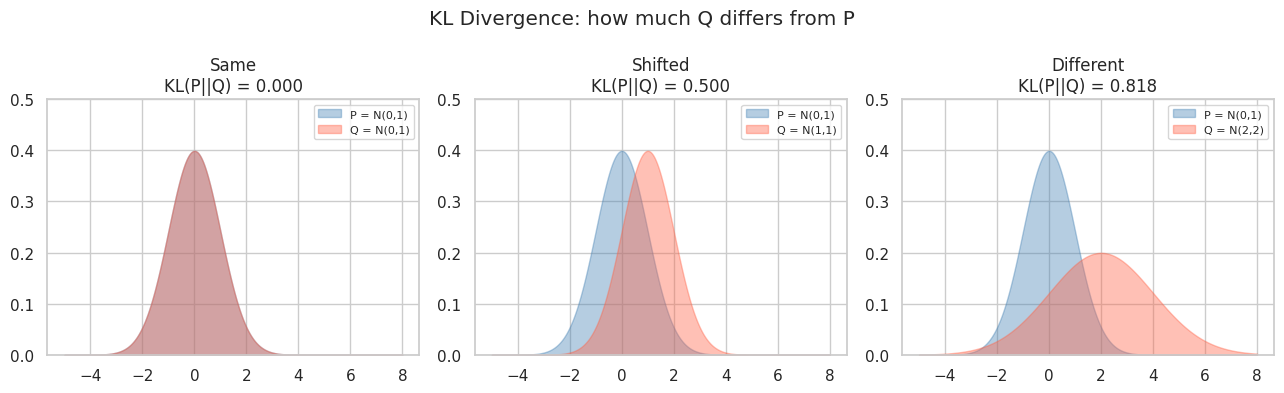

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy
from scipy.special import kl_div

# ── Discrete KL divergence ───────────────────────────────────────────────────
P = np.array([0.4, 0.3, 0.2, 0.1])  # reference (true distribution)
Q1 = np.array([0.4, 0.3, 0.2, 0.1])  # identical
Q2 = np.array([0.3, 0.3, 0.3, 0.1])  # slightly different
Q3 = np.array([0.1, 0.1, 0.1, 0.7])  # very different

print('Discrete KL divergence KL(P || Q):')
for label, Q in [('Q1 (identical)', Q1), ('Q2 (slight diff)', Q2), ('Q3 (very diff)', Q3)]:
    kl = scipy_entropy(P, Q)   # scipy entropy(P, Q) = KL(P||Q)
    kl_rev = scipy_entropy(Q, P)
    print(f'  {label:18s}: KL(P||Q)={kl:.4f}  KL(Q||P)={kl_rev:.4f}  <- asymmetry')

# ── Continuous KL divergence between Gaussians ───────────────────────────────
# KL(N(mu1,s1) || N(mu2,s2)) = log(s2/s1) + (s1² + (mu1-mu2)²)/(2*s2²) - 0.5
def kl_gaussians(mu1, s1, mu2, s2):
    return np.log(s2/s1) + (s1**2 + (mu1-mu2)**2) / (2*s2**2) - 0.5

print('\nContinuous KL between Gaussians:')
for mu2, s2, label in [(0, 1, 'Same N(0,1)'),
                        (1, 1, 'Shifted N(1,1)'),
                        (0, 2, 'Wider N(0,2)'),
                        (2, 3, 'Very different N(2,3)')]:
    kl = kl_gaussians(0, 1, mu2, s2)
    print(f'  KL(N(0,1) || N({mu2},{s2})): {kl:.4f}  — {label}')

# ── Visualise ─────────────────────────────────────────────────────────────────
x = np.linspace(-5, 8, 500)
from scipy.stats import norm
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ref = norm.pdf(x, 0, 1)
for ax, (mu, s, label) in zip(axes, [(0,1,'Same'), (1,1,'Shifted'), (2,2,'Different')]):
    q = norm.pdf(x, mu, s)
    ax.fill_between(x, ref, alpha=0.4, color='steelblue', label='P = N(0,1)')
    ax.fill_between(x, q,   alpha=0.4, color='tomato',    label=f'Q = N({mu},{s})')
    kl = kl_gaussians(0, 1, mu, s)
    ax.set_title(f'{label}\nKL(P||Q) = {kl:.3f}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 0.5)
plt.suptitle('KL Divergence: how much Q differs from P')
plt.tight_layout()
plt.show()


---
# 9. Advanced Topics